# 1. O DBSCAN klasteriranju

DBSCAN je algoritam klasteriranja baziran na gustoći.

Za razliku od K-Means algoritma, DBSCAN ne zahtijeva unaprijed zadavanje broja klastera. Umjesto toga koristi dva parametra:

- **`eps`** — radijus susjedstva,
- **`min_samples`** — minimalan broj točaka potreban da bi se točka smatrala jezgrenom točkom.

DBSCAN može identificirati klastere proizvoljnog oblika te označiti šum, odnosno točke koje ne pripadaju nijednom klasteru.

### Odabir parametara DBSCAN algoritma

Prije primjene DBSCAN algoritma potrebno je odrediti parametre **`eps`** i **`min_samples`**. Parametar **`eps`** definira maksimalnu udaljenost između dviju točaka kako bi se smatrale susjedima, dok **`min_samples`** određuje minimalan broj susjednih točaka potreban za formiranje jezgrene točke klastera.

U ovom radu odabrana je vrijednost **`min_samples = 20`**, čime se osigurava da klasteri sadrže dovoljan broj sličnih objekata te da se smanji osjetljivost algoritma na slučajne varijacije u podacima.

Za određivanje parametra **`eps`** korišten je k-distance graf. Za svaki objekt izračunata je udaljenost do njegovog 20. najbližeg susjeda, nakon čega su udaljenosti sortirane uzlazno. Vrijednost parametra eps odabire se u području nagle promjene nagiba krivulje, koja označava granicu između gusto povezanih objekata i potencijalnih anomalija.

Na temelju dobivenog grafa odabrana je vrijednost **`eps = 0.8`**, koja omogućuje formiranje smislenih klastera uz istovremeno izdvajanje netipičnih smještaja.



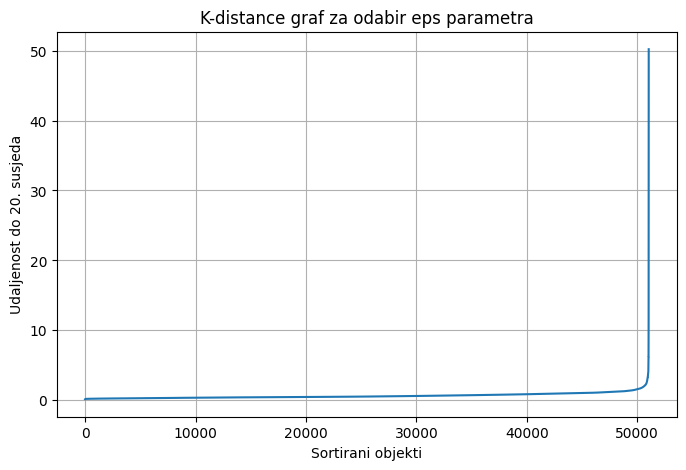

In [23]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# min_samples = 20 -> gledamo 20. susjeda
k = 20

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

# udaljenost do 20. susjeda
k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(8,5))
plt.plot(k_distances)
plt.xlabel("Sortirani objekti")
plt.ylabel("Udaljenost do 20. susjeda")
plt.title("K-distance graf za odabir eps parametra")
plt.grid(True)
plt.show()

## 2. Učitavanje podataka, odabir atributa, uzorkovanje

Za analizu se koristi skup podataka nakon prethodno provedenog feature engineeringa. Taj skup već sadrži dodatno konstruirane značajke poput udaljenosti od centra, omjera dostupnosti i mjere popularnosti smještaja.

Za DBSCAN su odabrani atributi koji opisuju cijenu, lokaciju, popularnost, dostupnost i ocjenu smještaja.

Korišteni atributi su:

- `price`
- `distance_to_center`
- `popularity_score`
- `availability_ratio`
- `review_rate_number`

Ovi atributi omogućuju analizu sličnosti smještaja prema ekonomskim, lokacijskim i korisničkim karakteristikama.


In [11]:
from google.colab import files

uploaded = files.upload()

Saving airbnb_features.csv to airbnb_features.csv


In [12]:
import pandas as pd

df = pd.read_csv("airbnb_features.csv")
df.head()

,id,name,host_id,host_identity_verified,host_name,neighbourhood_group,neighbourhood,lat,long,country,...,professional_host,neighborhood_avg_price,price_diff_neighborhood,distance_to_center,popularity_score,luxury_listing,high_price,room_type_encoded,neighbourhood_group_encoded,cancellation_policy_encoded
0,1001254,Clean & quiet apt home by the park,8.001449e+10,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,1,519.519337,446.480663,12.337898,-0.469815,0,1,2,1,2
1,1002102,Skylit Midtown Castle,5.233517e+10,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,0,521.095921,-379.095921,0.508366,0.321559,0,0,0,2,1
2,1002755,Water View King Bed Hotel Room,8.509833e+10,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,0,528.641953,-160.641953,8.387034,7.147646,0,0,0,1,1
3,1004650,BlissArtsSpace!,6.130061e+10,unconfirmed,Alberta,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,United States,...,0,526.145253,-455.145253,8.290747,1.198536,0,0,2,1,1
4,1006859,Cute & Cozy Lower East Side 1 bdrm,1.280143e+09,verified,Miranda,Manhattan,Chinatown,40.71344,-73.99037,United States,...,0,516.832061,-197.832061,4.971807,2.300431,0,0,0,2,0


In [14]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.8,
    min_samples=20,
    n_jobs=-1
)



In [18]:

dbscan_features = [
    "price",
    "distance_to_center",
    "popularity_score",
    "availability_ratio",
    "number_of_reviews",
    "reviews_per_month",
    "review_rate_number",
    "price_diff_neighborhood"
]

X_dbscan = df[dbscan_features].fillna(0)

## 3. Skaliranje podataka

DBSCAN koristi udaljenosti između točaka, pa je potrebno standardizirati podatke prije primjene algoritma.

Bez skaliranja bi atributi s većim numeričkim vrijednostima, primjerice cijena, imali nerazmjerno velik utjecaj na rezultat klasteriranja.

Standardizacijom se svaki atribut transformira tako da ima sredinu 0 i standardnu devijaciju 1.

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_dbscan)

## 4. Primjena DBSCAN algoritma

DBSCAN koristi dva ključna parametra:

- `eps`: radijus susjedstva oko svake točke,
- `min_samples`: minimalan broj točaka potreban da bi se neka točka smatrala jezgrenom točkom.

U ovoj analizi korišteni su parametri `eps = 0.8` i `min_samples = 10`.

Oznaka `-1` u rezultatima označava šum, odnosno smještaje koji nisu pridruženi nijednom klasteru.

In [20]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.8,
    min_samples=20,
    n_jobs=-1
)

labels = dbscan.fit_predict(X_scaled)

df["cluster"] = labels

print(df["cluster"].value_counts())

cluster
 3    9969
 1    9880
 0    9825
 4    9753
-1    8434
 2    3132
 5      19
 6      18
 7      15
Name: count, dtype: int64


In [21]:
dbscan_summary = df.groupby("cluster")[dbscan_features].mean()
dbscan_summary

,price,distance_to_center,popularity_score,availability_ratio,number_of_reviews,reviews_per_month,review_rate_number,price_diff_neighborhood
cluster,,,,,,,,
-1,529.873251,9.931875,2.773023,0.489456,104.849775,3.616055,3.238084,4.267235
0,527.007328,6.959014,-0.007132,0.360240,12.970789,0.867219,4.000000,0.974403
1,525.166194,6.945628,-0.810478,0.355861,13.295040,0.831195,3.000000,-0.914806
2,519.738506,6.211670,-2.618593,0.316041,12.017561,0.479483,1.000000,-6.667572
3,525.414786,6.879416,0.814252,0.356318,14.197312,0.883265,5.000000,-0.268778
4,524.346150,6.954798,-1.565620,0.362460,13.845483,0.869769,2.000000,-1.709904
5,711.894737,7.058695,-0.372822,0.192213,77.421053,2.162632,1.000000,182.159279
6,281.222222,2.144093,1.936593,0.128311,85.833333,3.133889,3.000000,-242.336983
7,856.266667,8.520829,1.052990,0.348311,106.200000,2.306667,2.000000,331.575621


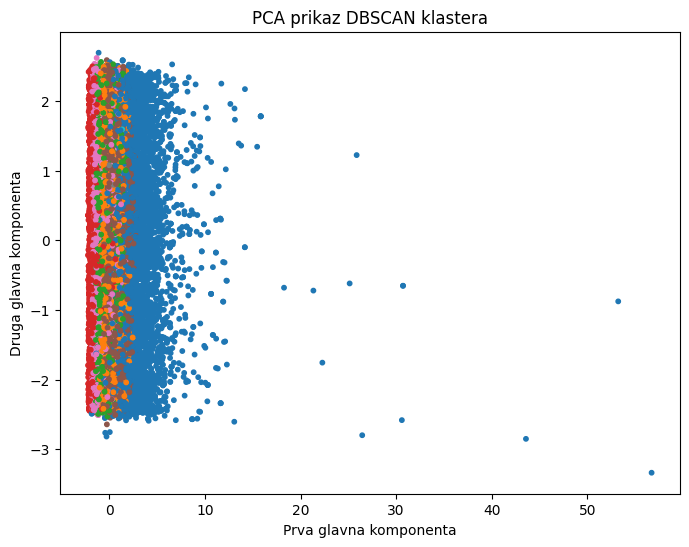

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels,
    cmap="tab10",
    s=10
)

plt.title("PCA prikaz DBSCAN klastera")
plt.xlabel("Prva glavna komponenta")
plt.ylabel("Druga glavna komponenta")
plt.show()

# 5. Interpretacija

Analiza prosječnih vrijednosti atributa pokazala je da se najveće razlike između klastera odnose na udaljenost od centra grada i pokazatelje popularnosti smještaja. Posebno se ističu objekti označeni kao šum (oznaka `-1`), koji imaju najveću prosječnu udaljenost od centra grada `(9,93 km)`, ali istovremeno ostvaruju najveće vrijednosti pokazatelja popularnosti i broja recenzija.

# 6. Zaključak
Rezultati su pokazali da DBSCAN identificira više klastera različitih veličina te značajan broj objekata označenih kao šum (oznaka `-1`). Za razliku od K-Means algoritma, koji je podatke podijelio na dvije velike skupine, DBSCAN je otkrio složeniju strukturu podataka i izdvojio smještaje koji odstupaju od dominantnih obrazaca.

